<a href="https://colab.research.google.com/github/moulinishyam3427-eng/AIML_LAB/blob/main/Stroke_Prediction_Six_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving stroke_processed_5k.csv to stroke_processed_5k.csv


In [5]:
df = pd.read_csv("stroke_processed_5k.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (5110, 11)

First 5 rows:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1.051434,0,1,1,2,1,2.706375,1.005086,1,1
1,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2,1
2,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2,1
3,0,0.255342,0,0,1,2,1,1.437358,0.719327,3,1
4,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2,1



Column Names:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 439.3 KB

Missing Values:
gender   

In [6]:
# Target variable
target = "stroke"

# Features
X = df.drop(columns=[target])

# Target
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget Distribution:")
print(y.value_counts())

print("\nTarget Percentage:")
print(y.value_counts(normalize=True) * 100)

Features:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

Target Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Target Percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4088, 10)
Testing data: (1022, 10)


In [8]:
ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

print("Before Oversampling:")
print(y_train.value_counts())

print("\nAfter Oversampling:")
print(y_train_balanced.value_counts())

Before Oversampling:
stroke
0    3889
1     199
Name: count, dtype: int64

After Oversampling:
stroke
0    3889
1    3889
Name: count, dtype: int64


In [9]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7
        ))
    ]),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

print("Six models created successfully!")

Six models created successfully!


In [10]:
results = []
trained_models = {}

for name, model in models.items():

    print("\nTraining:", name)

    # Train model
    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    # Store trained model
    trained_models[name] = model

    # Prediction
    y_pred = model.predict(X_test)

    # Probability prediction
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc
    })

print("\nAll models trained successfully!")


Training: Logistic Regression

Training: Decision Tree

Training: Random Forest

Training: SVM

Training: KNN

Training: ANN

All models trained successfully!


In [11]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "AUC-ROC": "{:.4f}"
    })
)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.7456,0.1379,0.8000,0.2353,0.8392
1,ANN,0.8513,0.1408,0.4000,0.2083,0.7732
2,Decision Tree,0.7407,0.1147,0.6400,0.1945,0.7369
3,SVM,0.7554,0.1094,0.5600,0.1830,0.7674
4,KNN,0.8200,0.0915,0.3000,0.1402,0.6192
5,Random Forest,0.9452,0.2000,0.0400,0.0667,0.8008


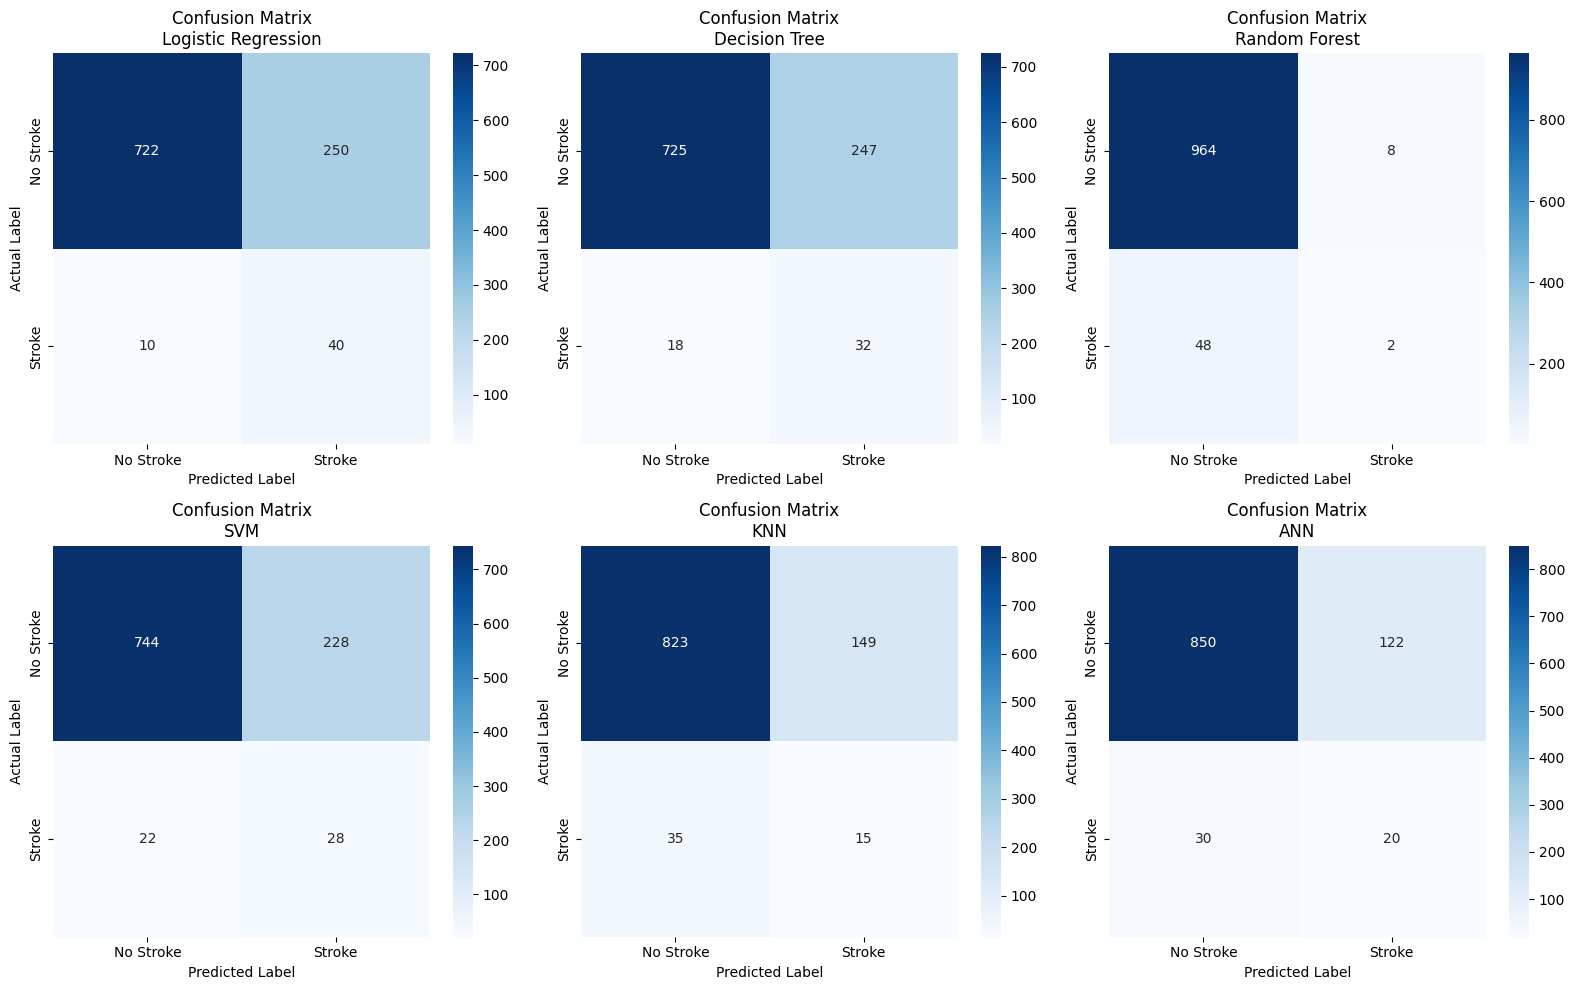

In [12]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.ravel()

for i, (name, model) in enumerate(trained_models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i]
    )

    axes[i].set_title(
        f"Confusion Matrix\n{name}"
    )

    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

    axes[i].set_xticklabels(
        ["No Stroke", "Stroke"]
    )

    axes[i].set_yticklabels(
        ["No Stroke", "Stroke"]
    )

plt.tight_layout()
plt.show()

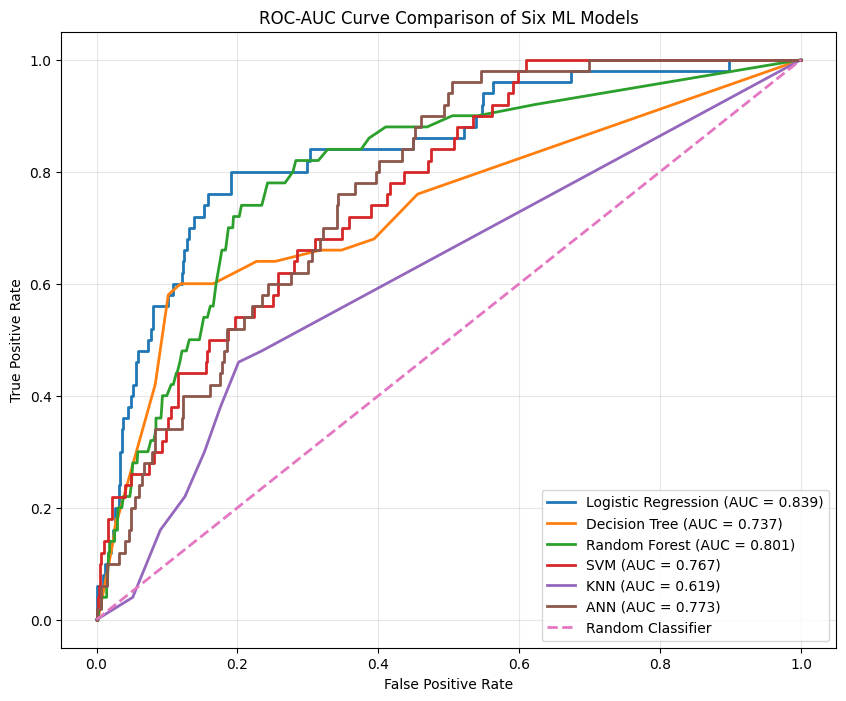

In [13]:
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC Curve Comparison of Six ML Models"
)

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [14]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Stroke",
                "Stroke"
            ],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

   No Stroke       0.99      0.74      0.85       972
      Stroke       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022


Decision Tree
              precision    recall  f1-score   support

   No Stroke       0.98      0.75      0.85       972
      Stroke       0.11      0.64      0.19        50

    accuracy                           0.74      1022
   macro avg       0.55      0.69      0.52      1022
weighted avg       0.93      0.74      0.81      1022


Random Forest
              precision    recall  f1-score   support

   No Stroke       0.95      0.99      0.97       972
      Stroke       0.20      0.04      0.07        50

    accuracy                           0.95      1022
   macro avg       0.58      0.52      0.52      1022
weighted avg       0.92

In [15]:
top_3 = results_df.head(3)

print("TOP 3 MODELS FOR STROKE RISK PREDICTION")
print("=" * 60)

display(
    top_3.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "AUC-ROC": "{:.4f}"
    })
)

TOP 3 MODELS FOR STROKE RISK PREDICTION


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.7456,0.1379,0.8000,0.2353,0.8392
1,ANN,0.8513,0.1408,0.4000,0.2083,0.7732
2,Decision Tree,0.7407,0.1147,0.6400,0.1945,0.7369


In [16]:
top_3 = results_df.head(3)

print("TOP 3 MODELS FOR STROKE RISK PREDICTION")
print("=" * 60)

display(
    top_3.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "AUC-ROC": "{:.4f}"
    })
)

TOP 3 MODELS FOR STROKE RISK PREDICTION


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.7456,0.1379,0.8000,0.2353,0.8392
1,ANN,0.8513,0.1408,0.4000,0.2083,0.7732
2,Decision Tree,0.7407,0.1147,0.6400,0.1945,0.7369


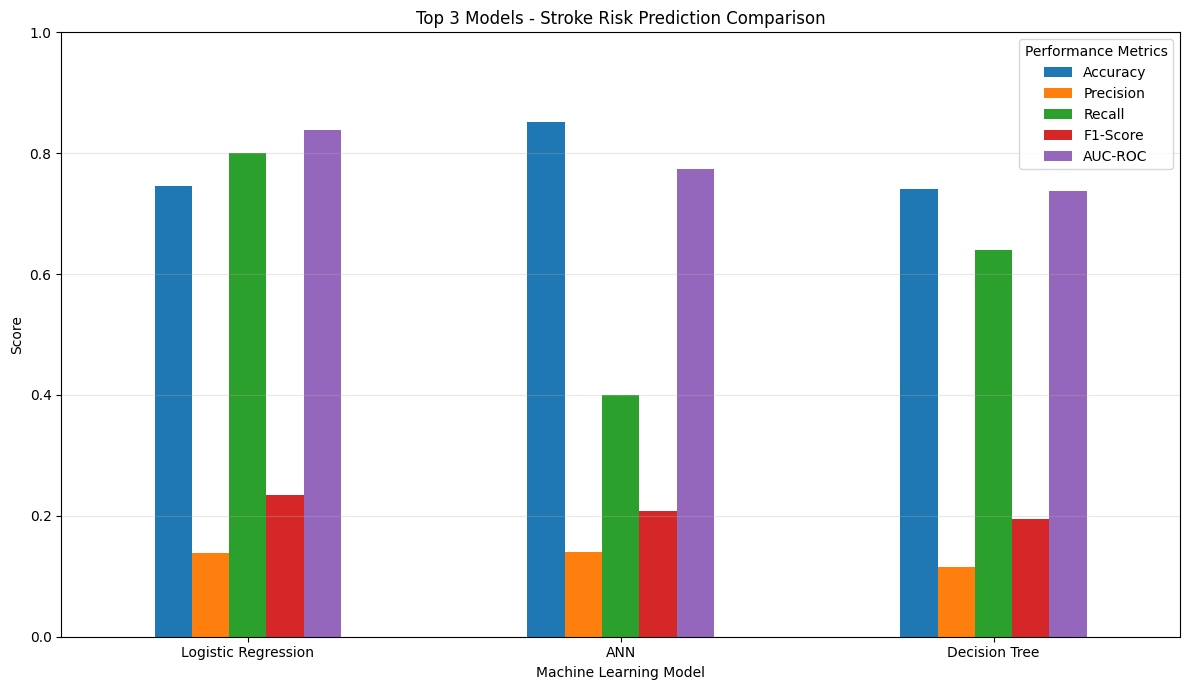

In [17]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

top3_plot = top_3.set_index("Model")[metrics]

ax = top3_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Top 3 Models - Stroke Risk Prediction Comparison"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Performance Metrics"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

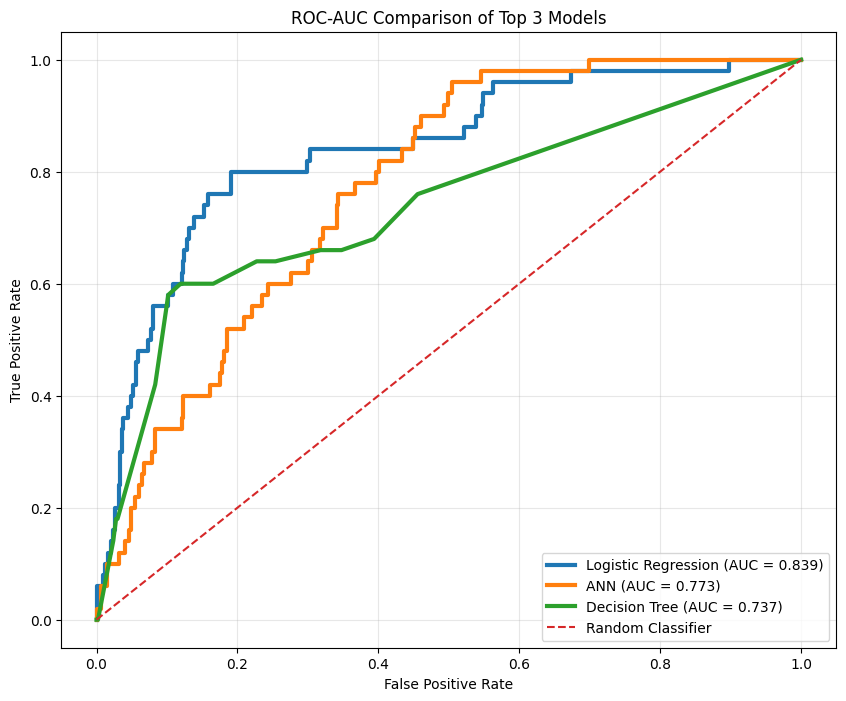

In [18]:
plt.figure(figsize=(10, 8))

for name in top_3["Model"]:

    model = trained_models[name]

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC Comparison of Top 3 Models"
)

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [19]:
print("=" * 75)
print("FINAL STROKE RISK PREDICTION ANALYSIS")
print("=" * 75)

for i, row in top_3.reset_index(drop=True).iterrows():

    print(f"\n{i+1}. {row['Model']}")
    print(f" Accuracy  : {row['Accuracy']:.4f}")
    print(f" Precision : {row['Precision']:.4f}")
    print(f" Recall    : {row['Recall']:.4f}")
    print(f" F1-Score  : {row['F1-Score']:.4f}")
    print(f" AUC-ROC   : {row['AUC-ROC']:.4f}")

print("\n" + "=" * 75)

best_f1_model = top_3.iloc[0]["Model"]

print(
    f"\nBased on F1-Score, the top model is: {best_f1_model}"
)

print(
    "\nThe models were evaluated using Accuracy, Precision, "
    "Recall, F1-Score, AUC-ROC and Confusion Matrix."
)

FINAL STROKE RISK PREDICTION ANALYSIS

1. Logistic Regression
 Accuracy  : 0.7456
 Precision : 0.1379
 Recall    : 0.8000
 F1-Score  : 0.2353
 AUC-ROC   : 0.8392

2. ANN
 Accuracy  : 0.8513
 Precision : 0.1408
 Recall    : 0.4000
 F1-Score  : 0.2083
 AUC-ROC   : 0.7732

3. Decision Tree
 Accuracy  : 0.7407
 Precision : 0.1147
 Recall    : 0.6400
 F1-Score  : 0.1945
 AUC-ROC   : 0.7369


Based on F1-Score, the top model is: Logistic Regression

The models were evaluated using Accuracy, Precision, Recall, F1-Score, AUC-ROC and Confusion Matrix.
